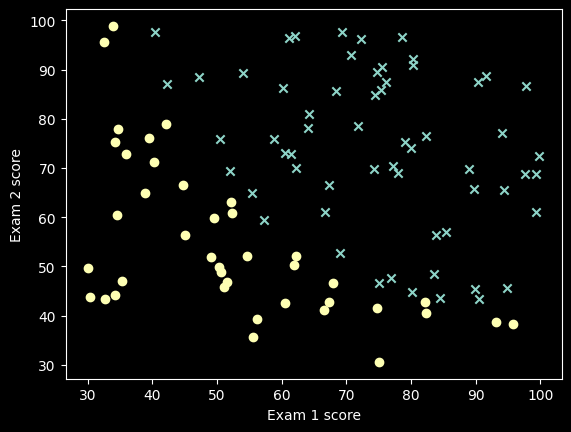

第 0 次迭代，当前损失为： 3.968530795912069 theta= [[0.0008     0.09607373 0.09010274]]
第 10000 次迭代，当前损失为： 5.587797624858964 theta= [[-6.12030894  0.16014133 -0.20361018]]


C:\Users\27341\AppData\Local\Temp\ipykernel_43884\2905804665.py:43: RuntimeWarning: divide by zero encountered in log
  z = -(y * np.log(h) + (1 - y) * np.log(1 - h))
C:\Users\27341\AppData\Local\Temp\ipykernel_43884\2905804665.py:43: RuntimeWarning: invalid value encountered in multiply
  z = -(y * np.log(h) + (1 - y) * np.log(1 - h))


第 20000 次迭代，当前损失为： nan theta= [[-12.09376582   0.52185091   0.20236407]]
第 30000 次迭代，当前损失为： 2.2663402576494165 theta= [[-17.7907633    0.34262922   0.09675745]]
第 40000 次迭代，当前损失为： 2.1973609797866795 theta= [[-23.08568468   0.21973928   0.04522011]]
第 50000 次迭代，当前损失为： nan theta= [[-28.05015864   0.54398296   0.38907359]]
第 40000 次迭代，当前损失为： 2.1973609797866795 theta= [[-23.08568468   0.21973928   0.04522011]]
第 50000 次迭代，当前损失为： nan theta= [[-28.05015864   0.54398296   0.38907359]]
第 60000 次迭代，当前损失为： 0.8176349486682629 theta= [[-31.53093049   0.23375202   0.20260575]]
第 70000 次迭代，当前损失为： 0.510974137143209 theta= [[-33.60314483   0.25919776   0.23031943]]
第 60000 次迭代，当前损失为： 0.8176349486682629 theta= [[-31.53093049   0.23375202   0.20260575]]
第 70000 次迭代，当前损失为： 0.510974137143209 theta= [[-33.60314483   0.25919776   0.23031943]]
第 80000 次迭代，当前损失为： 1.4097956454764213 theta= [[-35.1742097    0.3658641    0.33558335]]
第 90000 次迭代，当前损失为： nan theta= [[-37.04600717   0.45235131   0.40133168]]
第 8000

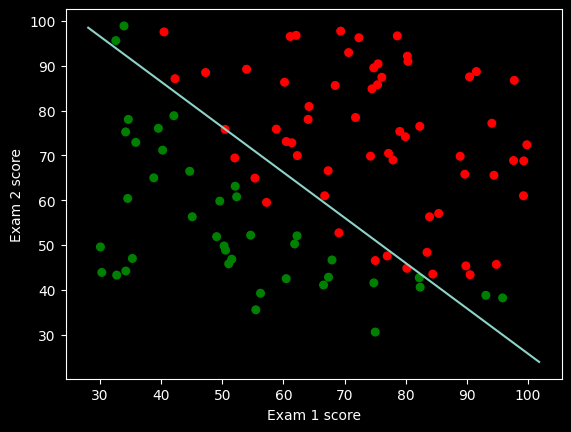

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.metrics import accuracy_score


def loaddata():
    data = np.loadtxt("data1.txt", delimiter=",")
    n = data.shape[1] - 1  # 特征数
    X = data[:, 0:n]
    y = data[:, -1].reshape(-1, 1)
    return X, y


def plot(X, y):
    pos = np.where(y == 1)
    neg = np.where(y == 0)
    plt.scatter(X[pos[0], 0], X[pos[0], 1], marker="x")
    plt.scatter(X[neg[0], 0], X[neg[0], 1], marker="o")
    plt.xlabel("Exam 1 score")
    plt.ylabel("Exam 2 score")
    plt.show()


X, y = loaddata()
plot(X, y)


def sigmoid(z):
    r = 1 / (1 + np.exp(-z))
    return r


def hypothesis(X, theta):
    z = np.dot(X, theta)
    return sigmoid(z)


def computeCost(X, y, theta):
    m = X.shape[0]
    # 补充计算代价的代码；
    h = hypothesis(X, theta)
    z = -(y * np.log(h) + (1 - y) * np.log(1 - h))
    return np.sum(z) / m
#########################

def gradientDescent(X, y, theta, iterations, alpha):
    # 取数据条数
    m = X.shape[0]
    # 在x最前面插入全1的列
    X = np.hstack((np.ones((m, 1)), X))
    cost_history = []  # 记录损失历史
    for i in range(iterations):
        # 补充参数更新代码；
        h = hypothesis(X, theta)
        gradient = (1 / m) * np.dot(X.T, (h - y))
        theta_temp = theta - alpha * gradient
        theta = theta_temp
        # 记录当前损失
        cost = computeCost(X, y, theta)
        cost_history.append(cost)
        # 每迭代10000次输出一次损失值
        if i % 10000 == 0:
            print(
                "第",
                i,
                "次迭代，当前损失为：",
                cost,
                "theta=",
                theta.T,
            )
    return theta, cost_history


def predict(X):
    # 在x最前面插入全1的列
    c = np.ones(X.shape[0]).transpose()
    X = np.insert(X, 0, values=c, axis=1)
    # 求解假设函数的值
    h = hypothesis(X, theta)
    # 根据概率值决定最终的分类,>=0.5为1类，<0.5为0类
    h[h >= 0.5] = 1
    h[h < 0.5] = 0
    return h


X, y = loaddata()
n = X.shape[1]  # 特征数
theta = np.zeros(n + 1).reshape(n + 1, 1)
# theta是列向量,+1是因为求梯度时X前会增加一个全1列
theta_temp = np.zeros(n + 1).reshape(n + 1, 1)
iterations = 250000
alpha = 0.008

theta, cost_history = gradientDescent(X, y, theta, iterations, alpha)
print("theta=\n", theta)


def plotDescisionBoundary(X, y, theta):
    cm_dark = mpl.colors.ListedColormap(["g", "r"])
    plt.xlabel("Exam 1 score")
    plt.ylabel("Exam 2 score")
    plt.scatter(X[:, 0], X[:, 1], c=np.array(y).squeeze(), cmap=cm_dark, s=30)
    # 补充画决策边界代码；
    x1 = np.array([np.min(X[:, 0]) - 2, np.max(X[:, 0]) + 2])
    x2 = (-1 / theta[2]) * (theta[1] * x1 + theta[0])
    plt.plot(x1, x2)
    plt.show()


plotDescisionBoundary(X, y, theta)


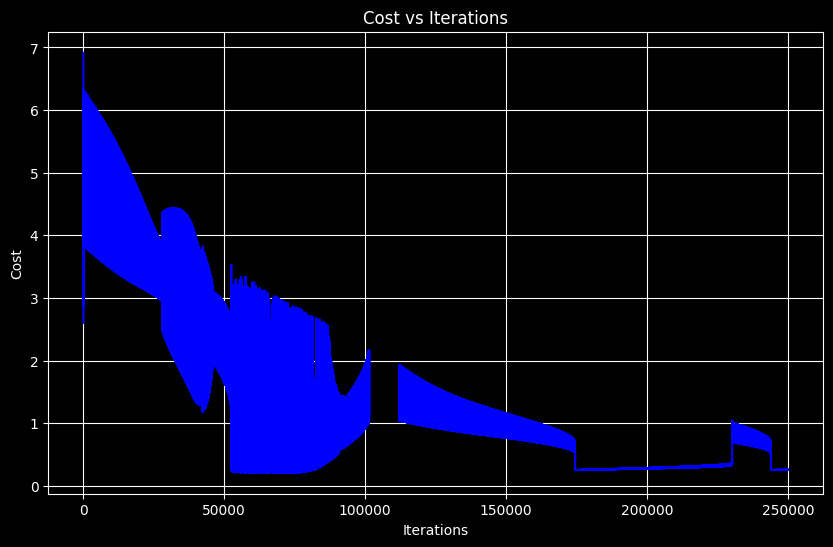

In [18]:
# 绘制损失变化图
plt.figure(figsize=(10, 6))
plt.plot(range(len(cost_history)), cost_history, 'b-')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost vs Iterations')
plt.grid(True)
plt.show()

In [19]:
# 基于训练得到的参数，输入新的样本数据，输出预测值
print("\n==== 新样本预测 ====")

# 示例1: 考试1分数45，考试2分数85
test_sample1 = np.array([[45, 85]])
prediction1 = predict(test_sample1)
prob1 = hypothesis(np.insert(test_sample1, 0, 1, axis=1), theta)
print(f"样本1 (Exam1=45, Exam2=85):")
print(f"  预测类别: {int(prediction1[0, 0])}")
print(f"  预测概率: {prob1[0, 0]:.4f}")

# 示例2: 考试1分数60，考试2分数60
test_sample2 = np.array([[60, 60]])
prediction2 = predict(test_sample2)
prob2 = hypothesis(np.insert(test_sample2, 0, 1, axis=1), theta)
print(f"\n样本2 (Exam1=60, Exam2=60):")
print(f"  预测类别: {int(prediction2[0, 0])}")
print(f"  预测概率: {prob2[0, 0]:.4f}")


==== 新样本预测 ====
样本1 (Exam1=45, Exam2=85):
  预测类别: 1
  预测概率: 0.7979

样本2 (Exam1=60, Exam2=60):
  预测类别: 0
  预测概率: 0.0878
